In [3]:
import torch

import triton
import triton.language as tl

try:
    import apex
    HAS_APEX = True
except ModuleNotFoundError:
    HAS_APEX = False

DEVICE = triton.runtime.driver.active.get_active_torch_device()
print(DEVICE, HAS_APEX)

cuda:0 False


In [4]:
@triton.jit
def add_kernel(x_ptr, y_ptr, output_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets<n_elements
    x = tl.load(x_ptr+offsets,mask=mask)
    y = tl.load(y_ptr+offsets,mask=mask)
    output = x+y
    tl.store(output_ptr+offsets, output,mask=mask)

def add(X, Y):
    output = torch.empty_like(X)
    assert X.device ==DEVICE and Y.device ==DEVICE and output.device ==DEVICE
    n_elements = output.numel()
    grid = lambda meta: ((n_elements+meta['BLOCK_SIZE']-1)//meta['BLOCK_SIZE'],)
    add_kernel[grid](X,Y,output,n_elements,BLOCK_SIZE=512)
    return output


In [5]:
torch.manual_seed(42)
size = 98432
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x+y
output_triton = add(x,y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([1.6007, 0.1390, 0.9605,  ..., 1.4328, 0.8217, 1.2138], device='cuda:0')
tensor([1.6007, 0.1390, 0.9605,  ..., 1.4328, 0.8217, 1.2138], device='cuda:0')
The maximum difference between torch and triton is 0.0


In [6]:
import torch.nn as nn

class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias = nn.Parameter(torch.zeros(dim))
    
    def forward(self, x):
        mean = x.mean(dim = -1, keepdim=True)
        var = x.var(dim = -1, keepdim=True, unbiased = False)

        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return x_norm * self.weight + self.bias
    
batch_size, seq_len, hidden_dim = 2, 128, 4096
x = torch.randn(batch_size, seq_len, hidden_dim)
layer_norm = LayerNorm(hidden_dim)
output = layer_norm(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Output mean:\n{output.mean(axis=2)}")
print(f"Output std:\n{output.std(axis=2, correction=0)}")

Input shape: torch.Size([2, 128, 4096])
Output shape: torch.Size([2, 128, 4096])
Output mean:
tensor([[-6.8685e-09, -1.3970e-09, -3.4925e-09, -1.4494e-08, -9.3132e-10,
          8.8476e-09,  2.1188e-08,  1.0245e-08, -1.5134e-08, -1.3039e-08,
         -3.9581e-09, -1.5832e-08,  1.4901e-08, -4.8894e-09, -1.3970e-09,
          1.8626e-09,  5.5879e-09, -5.5879e-09, -5.3551e-09,  7.2177e-09,
         -3.2596e-09, -8.8476e-09,  3.9581e-09, -1.1176e-08, -1.3039e-08,
         -8.3819e-09, -8.3819e-09, -1.3970e-09,  6.0536e-09,  1.2107e-08,
         -9.3132e-10,  1.0245e-08, -3.2596e-09,  4.2492e-09, -1.3970e-09,
         -3.7253e-09,  2.3283e-09, -1.1642e-08,  2.3283e-10,  3.6089e-09,
         -1.4901e-08, -9.5461e-09, -1.1642e-08,  6.0536e-09,  8.3819e-09,
          4.6566e-09,  1.1642e-08, -5.5879e-09, -9.3132e-09,  9.3132e-09,
          1.8859e-08, -3.7253e-09, -1.5832e-08, -6.0536e-09,  1.3504e-08,
         -1.0245e-08,  6.5193e-09,  9.3132e-09,  9.0804e-09, -2.7940e-09,
          4.5402e-

In [40]:
@triton.jit
def _layer_norm_fwd_fused(X, Y, W, B, Mean, Rstd, stride, N, eps, BLOCK_SIZE: tl.constexpr):
    row = tl.program_id(0)
    Y += row * stride
    X += row * stride

    mean = 0
    _mean = tl.zeros([BLOCK_SIZE], dtype=tl.float32)
    for off in range(0, N, BLOCK_SIZE):
        cols = off + tl.arange(0, BLOCK_SIZE)
        a = tl.load(X+cols,mask=cols<N, other=0.).to(tl.float32)
        _mean+=a
    mean = tl.sum(_mean, axis=0)/N
    _var = tl.zeros([BLOCK_SIZE],dtype=tl.float32)
    for off in range(0, N, BLOCK_SIZE):
        cols = off+ tl.arange(0, BLOCK_SIZE)
        x = tl.load(X+cols, mask=cols<N, other=0.).to(tl.float32)
        x = tl.where(cols<N, x-mean,0.)
        _var += x*x
    var = tl.sum(_var, axis=0)/N
    rstd = 1/tl.sqrt(var+eps)
    tl.store(Mean+row, mean)
    tl.store(Rstd+row, rstd)
    for off in range(0, N, BLOCK_SIZE):
        cols = off+tl.arange(0, BLOCK_SIZE)
        mask = cols<N
        w = tl.load(W+cols, mask=mask)
        b = tl.load(B+cols, mask=mask)
        x = tl.load(X+cols, mask=mask, other=0.).to(tl.float32)
        x_hat = (x - mean) *rstd
        y = x_hat * w + b
        tl.store(Y+cols, y, mask=mask)



In [41]:
class LayerNorm(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, normalized_shape, weight, bias, eps):
        y = torch.empty_like(x)
        x_arg = x.reshape(-1, x.shape[-1])
        M, N = x_arg.shape
        mean = torch.empty((M, ), dtype=torch.float32, device = x.device)
        rstd = torch.empty((M, ), dtype=torch.float32, device = x.device)
        MAX_FUSED_SIZE = 65536 // x.element_size()
        BLOCK_SIZE = min(MAX_FUSED_SIZE, triton.next_power_of_2(N))
        # if N > BLOCK_SIZE:
        #     raise RuntimeError("This layer norm doesn't support feature dim >= 64KB.")
        num_warps = min(max(BLOCK_SIZE // 256, 1), 8)
        _layer_norm_fwd_fused[(M, )](  #
            x_arg, y, weight, bias, mean, rstd,  #
            x_arg.stride(0), N, eps,  #
            BLOCK_SIZE=BLOCK_SIZE, num_warps=num_warps, num_ctas=1
        )
        ctx.save_for_backward(x, weight, bias, mean, rstd)
        ctx.BLOCK_SIZE = BLOCK_SIZE
        ctx.num_warps = num_warps
        ctx.eps = eps
        return y

layer-norm:
          N  Triton (GB/s)  Torch (GB/s)
0    1024.0     227.555548    218.407832
1    1536.0     233.778834    222.218710
2    2048.0     237.449270    226.425389
3    2560.0     239.226134    213.576669
4    3072.0     240.941181    194.384724
5    3584.0     242.373262    182.207128
6    4096.0     239.893846    174.835517
7    4608.0     239.328056    169.100917
8    5120.0     227.092298    167.301047
9    5632.0     216.631664    165.647056
10   6144.0     206.521014    164.905004
11   6656.0     197.775630    164.124055
12   7168.0     189.664912    163.774202
13   7680.0     181.238943    160.045591
14   8192.0     172.081065    164.631003
15   8704.0     207.348984    159.340958
16   9216.0     213.086714    163.148878
17   9728.0     216.149641    162.870283
18  10240.0     218.226017    163.019810
19  10752.0     207.760268    162.591523
20  11264.0     214.154024    162.698332
21  11776.0     207.531609    162.449467
22  12288.0     208.561161    162.754967
23  

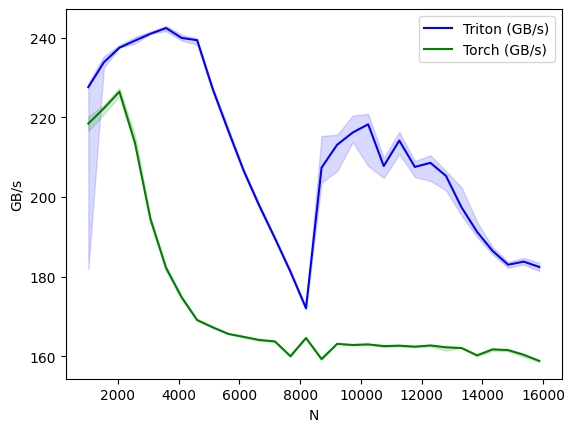

In [42]:
layer_norm = LayerNorm.apply

def test_layer_norm(M, N, dtype, eps=1e-5, device=DEVICE):
    x_shape = (M, N)
    w_shape = (x_shape[-1],)
    weight = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    bias = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    x = -2.3 + 0.5 * torch.randn(x_shape, dtype=dtype, device=device)
    dy = .1 * torch.randn_like(x)
    x.requires_grad_(True)
    y_tri = layer_norm(x, w_shape, weight, bias, eps)
    y_ref = torch.nn.functional.layer_norm(x, w_shape, weight, bias, eps).to(dtype)

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[512 * i for i in range(2, 32)],
        line_arg='provider',
        line_vals=['triton','torch'],
        line_names=['Triton (GB/s)','Torch (GB/s)'],
        styles=[('blue','-'),('green','-'),('orange','-')],
        ylabel='GB/s',
        plot_name = 'layer-norm',
        args={'M':4096,'dtype':torch.float16,'mode':'backward'},
    )
)
def bench_layer_norm(M, N, dtype, provider, mode='forward', eps=1e-5, device=DEVICE):
    x_shape = (M, N)
    w_shape = (x_shape[-1],)
    weight = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    bias = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    x = -2.3 + 0.5 * torch.randn(x_shape, dtype=dtype, device=device)
    dy = .1 * torch.randn_like(x)
    x.requires_grad_(True)
    quantiles = [0.5, 0.2, 0.8]

    def y_fwd():
        if provider == "triton":
            return layer_norm(x, w_shape, weight, bias, eps)
        if provider == "torch":
            return torch.nn.functional.layer_norm(x, w_shape, weight, bias, eps)
        
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9/(ms * 1e-3)
    ms, min_ms, max_ms = triton.testing.do_bench(y_fwd, quantiles=quantiles, rep=500)

    return gbps(ms), gbps(max_ms), gbps(min_ms)

test_layer_norm(1151, 8192, torch.float16)
bench_layer_norm.run(save_path='.', print_data=True)



In [43]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.dim = dim
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    
    def forward(self, x):
        rms = torch.rsqrt(x.pow(2).mean(dim=-1, keepdim=True)+self.eps)
        x_norm = x*rms
        return x_norm
    
batch_size, seq_len, hidden_dim = 2, 5, 8
x = torch.randn(batch_size, seq_len, hidden_dim)
rms_norm = RMSNorm(hidden_dim)
output = rms_norm(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Output RMS: {torch.sqrt((output**2).mean(axis=2))}")

Input shape: torch.Size([2, 5, 8])
Output shape: torch.Size([2, 5, 8])
Output RMS: tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])


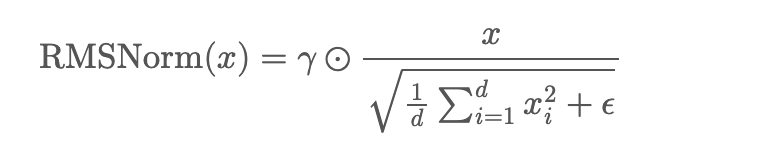

In [ ]:
@triton.jit
def _rms_norm_fwd(
    X,
    Y,
    W,
    Mean,
    stride,
    N,
    eps,
    BLOCK_SIZE: tl.constexpr,
):
    row = tl.program_id(0)
    Y += row * stride
    X += row * stride

    _sq_sum = tl.zeros([BLOCK_SIZE], dtype=tl.float32)
    for off in range(0, N, BLOCK_SIZE):
        cols = off + tl.arange(0, BLOCK_SIZE)
        a = tl.load(X+cols, mask=cols<N,other=0.).to(tl.float32)
        _sq_sum+=a*a
    mean = tl.sum(_sq_sum, axis=0)/N
    rmean = tl.rsqrt(mean + eps)
    tl.store(Mean+row,rmean)
    for off in range(0, N, BLOCK_SIZE):
        cols = off + tl.arange(0, BLOCK_SIZE)
        mask = cols < N
        w = tl.load(W+cols, mask=mask)
        x = tl.load(X+cols, mask=mask, other=0.).to(tl.float32)
        rms = w*x*rmean
        tl.store(Y+cols, rms, mask=mask)

    